In [ ]:
!pip install numpy pandas matplotlib

: 

In [ ]:
#!/usr/bin/env python3

import csv, pathlib, sys

noise=0.05
angle=180

SRC_DIR = pathlib.Path(f'data_vicsek_scalar/Angle_{angle}/Noise_{noise}/config_data/')          # root that contains trial_*/
XYZ_DIR = 'xyz'                                # sub-folder that will hold .xyz files
SPECIES = 'A'                                  # same species for every particle

def csv_to_xyz(csv_path, xyz_path):
    """Read x,y,vx,vy csv and write minimal xyz file."""
    with csv_path.open(newline='') as fc, xyz_path.open('w') as fx:
        rows = list(csv.DictReader(fc))          # first line is header
        fx.write(f'{len(rows)}\n')
        fx.write('Properties=id:I:1:pos:R:2:velo:R:2:species:S:1\n')
        for i, r in enumerate(rows):
            x, y   = float(r['x']), float(r['y'])
            vx, vy = float(r['vx']), float(r['vy'])
            fx.write(f'{i} {x} {y} {vx} {vy} {SPECIES}\n')

def main():
    if not SRC_DIR.is_dir():
        sys.exit(f'Folder {SRC_DIR} not found – run this script from the project root.')

    trials = [d for d in SRC_DIR.iterdir() if d.is_dir() and d.name.startswith('trial_')]
    if not trials:
        sys.exit('No trial_*/ directories inside config_data/')

    for trial in trials:
        csv_folder = trial
        xyz_folder = trial / XYZ_DIR
        xyz_folder.mkdir(exist_ok=True)

        csv_files = sorted(csv_folder.glob('config_*.csv'))
        if not csv_files:
            print(f'No cLsv files in {trial}, skipping')
            continue

        for csv_file in csv_files:
            num = csv_file.stem.split('_')[1]          # config_123.csv → 123
            xyz_file = xyz_folder / f'config_{num}.xyz'
            csv_to_xyz(csv_file, xyz_file)

        print(f'converted {len(csv_files)} snapshots → {xyz_folder}')

if __name__ == '__main__':
    main()

converted 37 snapshots → data_vicsek_scalar/Angle_180/Noise_0.05/config_data/trial_0/xyz
converted 37 snapshots → data_vicsek_scalar/Angle_180/Noise_0.05/config_data/trial_1/xyz
converted 37 snapshots → data_vicsek_scalar/Angle_180/Noise_0.05/config_data/trial_2/xyz
converted 37 snapshots → data_vicsek_scalar/Angle_180/Noise_0.05/config_data/trial_3/xyz
converted 37 snapshots → data_vicsek_scalar/Angle_180/Noise_0.05/config_data/trial_4/xyz


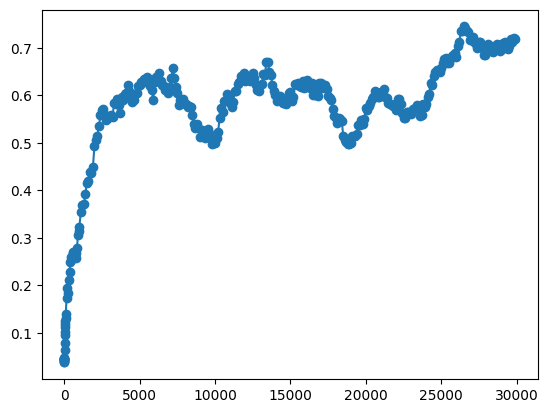

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
data=pd.read_csv("data/order_data/order_parameter_0_.csv")
plt.plot(data["t"],data["va"],marker="o")
plt.show()